## 2. Import Required Libraries

In [1]:
# EDA tools
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(10)
import warnings
warnings.filterwarnings("ignore")

#Single model classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

#Ensemble classifications models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#Model evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics._scorer import _SCORERS
from sklearn.metrics import (accuracy_score,confusion_matrix, classification_report, roc_auc_score,
f1_score, recall_score, precision_score)
import time

# Imbalance, Hyperparameter tunning and pipelines
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

## 3. Exploratory Data Analysis


In [2]:
#Load the file into a pandas data frame.
data = pd.read_csv("diabetes.csv")
#Get structural information of the data set.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [3]:
#Visualize first 5 rows of data of the first 12 columns.
data.head().iloc[:,:12]

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN


In [4]:
#Visualize first 5 rows of data of the remaining columns.
data.head().iloc[:,12:]

,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,41,0,1,0,0,0,250.83,NaN,NaN,1,...,No,No,No,No,No,No,No,No,No,NO
1,59,0,18,0,0,0,276,250.01,255,9,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,11,5,13,2,0,1,648,250,V27,6,...,No,No,No,No,No,No,No,No,Yes,NO
3,44,1,16,0,0,0,8,250.43,403,7,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,51,0,8,0,0,0,197,157,250,5,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
#Look for missing values.
data.isna().any()

encounter_id                False
patient_nbr                 False
race                         True
gender                      False
age                         False
weight                       True
admission_type_id           False
discharge_disposition_id    False
admission_source_id         False
time_in_hospital            False
payer_code                   True
medical_specialty            True
num_lab_procedures          False
num_procedures              False
num_medications             False
number_outpatient           False
number_emergency            False
number_inpatient            False
diag_1                       True
diag_2                       True
diag_3                       True
number_diagnoses            False
max_glu_serum                True
A1Cresult                    True
metformin                   False
repaglinide                 False
nateglinide                 False
chlorpropamide              False
glimepiride                 False
acetohexamide 

In [6]:
#Do data preprocessing on missing values
cols_to_drop = ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code']
data = data.drop(columns=cols_to_drop)
data.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [7]:
# Remove columns with only one unique value
data = data.drop(columns=['citoglipton', 'examide'])
data.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [8]:
#For the "race" column, which is a categorical feature and already includes an "Other" category, we will assign all missing values to "Other"
data['race'] = data['race'].fillna('Other')

In [9]:
def icd9_to_numeric(icd_code):
    if pd.isna(icd_code) or icd_code == 'Unknown':
        return 0
    code_str = str(icd_code)
    if code_str.startswith('E') or code_str.startswith('V'):
        return 1000
    try:
        # Keep only the integer part before decimal point
        return int(float(code_str))
    except:
        return 0 

# Process three diagnosis features
data['diag_1_numeric'] = data['diag_1'].apply(icd9_to_numeric)
data['diag_2_numeric'] = data['diag_2'].apply(icd9_to_numeric)
data['diag_3_numeric'] = data['diag_3'].apply(icd9_to_numeric)

# Delete diag_1, diag_2, diag_3 columns
data = data.drop(columns=['diag_1', 'diag_2', 'diag_3'])
data.head()

# Rename diag_1_numeric, diag_2_numeric, diag_3_numeric columns to diag_1, diag_2, diag_3
data = data.rename(columns={'diag_1_numeric': 'diag_1', 'diag_2_numeric': 'diag_2', 'diag_3_numeric': 'diag_3'})
data.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,diag_1,diag_2,diag_3
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,NO,250,0,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,No,No,No,Ch,Yes,>30,276,250,255
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,Yes,NO,648,250,1000
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,No,No,No,Ch,Yes,NO,8,250,403
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,No,No,No,Ch,Yes,NO,197,157,250


In [10]:
def age_to_mid(age_str):
    # age_str is in the format "[20-30)"
    if isinstance(age_str, str) and '-' in age_str:
        nums = age_str.replace('[','').replace(')','').split('-')
        return (int(nums[0]) + int(nums[1])) // 2
    else:
        return None

data['age'] = data['age'].apply(age_to_mid)
data['age'].head()

0     5
1    15
2    25
3    35
4    45
Name: age, dtype: int64

In [11]:
data['readmitted'] = data['readmitted'].apply(lambda x: 'YES' if x == '<30' else 'NO')
data['readmitted'].value_counts()

readmitted
NO     90409
YES    11357
Name: count, dtype: int64

In [12]:
drug_columns = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
] # exclude 'citoglipton' and 'examide' for they had been removed

# count the total number of medications used by each patient (as long as it's not "No", it's considered used)
data['num_drugs'] = data[drug_columns].apply(lambda row: sum(row != 'No'), axis=1)

In [13]:
# Create combined feature: admission_type_source
def create_admission_combination(row):
    admission_type = row['admission_type_id']
    admission_source = row['admission_source_id']
    
    # Combinations based on business logic
    if admission_type == 1 and admission_source == 7:  # Emergency + ER
        return 'Emergency_ER'
    elif admission_type == 2 and admission_source == 1:  # Urgent + Physician
        return 'Urgent_Physician'
    elif admission_type == 3 and admission_source == 1:  # Elective + Physician
        return 'Elective_Physician'
    elif admission_type == 2 and admission_source == 7:  # Urgent + ER
        return 'Urgent_ER'
    else:
        return 'Other_Combination'

# Apply combined feature
data['admission_type_source'] = data.apply(create_admission_combination, axis=1)

# Delete original two columns
data.drop(['admission_type_id', 'admission_source_id'], axis=1, inplace=True)

data.head()

,encounter_id,patient_nbr,race,gender,age,discharge_disposition_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,diag_1,diag_2,diag_3,num_drugs,admission_type_source
0,2278392,8222157,Caucasian,Female,5,25,1,41,0,1,...,No,No,No,No,NO,250,0,0,0,Other_Combination
1,149190,55629189,Caucasian,Female,15,1,3,59,0,18,...,No,No,Ch,Yes,NO,276,250,255,1,Emergency_ER
2,64410,86047875,AfricanAmerican,Female,25,1,2,11,5,13,...,No,No,No,Yes,NO,648,250,1000,1,Emergency_ER
3,500364,82442376,Caucasian,Male,35,1,2,44,1,16,...,No,No,Ch,Yes,NO,8,250,403,1,Emergency_ER
4,16680,42519267,Caucasian,Male,45,1,1,51,0,8,...,No,No,Ch,Yes,NO,197,157,250,2,Emergency_ER


In [14]:
#drop encounter_id	patient_nbr	 columns. Not relevant

data.drop(['encounter_id', 'patient_nbr'], axis=1, inplace=True)

In [15]:
data.describe().iloc[:,:12]

,age,discharge_disposition_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,diag_1,diag_2
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,65.967022,3.715642,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607,501.629130,451.103060
std,15.940838,5.280166,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600,214.898338,198.686789
min,5.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,55.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,410.000000,276.000000
50%,65.000000,1.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,441.000000,427.000000
75%,75.000000,4.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,599.000000,569.000000
max,95.000000,28.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,1000.000000,1000.000000


In [16]:
data.describe().iloc[:,12:]

,diag_3,num_drugs
count,101766.000000,101766.000000
mean,441.231168,1.179706
std,219.514279,0.920190
min,0.000000,0.000000
25%,274.000000,1.000000
50%,411.000000,1.000000
75%,535.000000,2.000000
max,1000.000000,6.000000


In [17]:
#Get number of unique values for each discrete variable in the dataset.
for col in data.describe().columns:
    if data[col].dtype == int:
        print(f'{col}:', data[col].nunique())

age: 10
discharge_disposition_id: 26
time_in_hospital: 14
num_lab_procedures: 118
num_procedures: 7
num_medications: 75
number_outpatient: 39
number_emergency: 33
number_inpatient: 21
number_diagnoses: 16
diag_1: 666
diag_2: 619
diag_3: 640
num_drugs: 7


In [18]:
#Get value counts for SpecialDay
data.readmitted.value_counts()

readmitted
NO     90409
YES    11357
Name: count, dtype: int64

In [19]:
#Get non-numerical features.
non_num_cols = list(set(data.columns) - set(data.describe().columns))
print('Non-numerical features: ',non_num_cols)

Non-numerical features:  ['glipizide', 'tolbutamide', 'glimepiride', 'troglitazone', 'glyburide-metformin', 'insulin', 'admission_type_source', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'pioglitazone', 'change', 'glyburide', 'chlorpropamide', 'glipizide-metformin', 'metformin', 'readmitted', 'gender', 'tolazamide', 'acarbose', 'metformin-pioglitazone', 'race', 'repaglinide', 'miglitol', 'rosiglitazone', 'diabetesMed', 'acetohexamide', 'nateglinide']


In [20]:
#Get numerical features.
num_cols = list(set(data.describe().columns))
print('Numerical features: ', num_cols)

Numerical features:  ['number_outpatient', 'number_emergency', 'age', 'num_medications', 'number_diagnoses', 'diag_3', 'diag_2', 'discharge_disposition_id', 'number_inpatient', 'num_lab_procedures', 'time_in_hospital', 'num_drugs', 'diag_1', 'num_procedures']


In [21]:
#remove irrelevant identifiers


#### 4.1 One-hot-code categorical features

In [22]:
#Create list with categorical features' names.
#data.readmitted[data.readmitted =='>30'] = 2
data.readmitted[data.readmitted =='YES'] = 1
data.readmitted[data.readmitted =='NO'] = 0

target = data.readmitted.copy()
non_num_cols.remove('readmitted')
data = data.drop(columns= ['readmitted'])
nonum_feats_names = non_num_cols

#Create list with numerical features' names.
num_cols_names = num_cols

In [23]:
#Assign appropriate data type to categorical variables.
nonum_feats = data[nonum_feats_names].astype('category')
nonum_feats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   glipizide                 101766 non-null  category
 1   tolbutamide               101766 non-null  category
 2   glimepiride               101766 non-null  category
 3   troglitazone              101766 non-null  category
 4   glyburide-metformin       101766 non-null  category
 5   insulin                   101766 non-null  category
 6   admission_type_source     101766 non-null  category
 7   glimepiride-pioglitazone  101766 non-null  category
 8   metformin-rosiglitazone   101766 non-null  category
 9   pioglitazone              101766 non-null  category
 10  change                    101766 non-null  category
 11  glyburide                 101766 non-null  category
 12  chlorpropamide            101766 non-null  category
 13  glipizide-metformin       101

In [24]:
#One-hot-code categorical variables and dropping the reference value.
ohc_feats = pd.get_dummies(nonum_feats,drop_first=True)
ohc_feats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 60 columns):
 #   Column                                   Non-Null Count   Dtype
---  ------                                   --------------   -----
 0   glipizide_No                             101766 non-null  bool 
 1   glipizide_Steady                         101766 non-null  bool 
 2   glipizide_Up                             101766 non-null  bool 
 3   tolbutamide_Steady                       101766 non-null  bool 
 4   glimepiride_No                           101766 non-null  bool 
 5   glimepiride_Steady                       101766 non-null  bool 
 6   glimepiride_Up                           101766 non-null  bool 
 7   troglitazone_Steady                      101766 non-null  bool 
 8   glyburide-metformin_No                   101766 non-null  bool 
 9   glyburide-metformin_Steady               101766 non-null  bool 
 10  glyburide-metformin_Up                   101766 non-null



### 4.2 Plain Vanilla Classification Models

The classifiers that I will be testing are:
* Logistic Regression
+ Decision Tree
* Random Forest
* Gradient Boosting

In [25]:
ohc_data = pd.concat([data[num_cols_names], ohc_feats],axis=1)
ohc_data = ohc_data.apply(pd.to_numeric)
target = target.apply(pd.to_numeric)
#results1 = baseline_models(data=[ohc_data,target], verbose=True)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(ohc_data, target, test_size = 0.25, random_state = 42)


In [27]:
from sklearn.utils.validation import column_or_1d
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.utils.validation import column_or_1d
logmodel = LogisticRegression(multi_class='multinomial', solver='lbfgs',class_weight = 'balanced', max_iter=20000)
y_train = column_or_1d(y_train, warn=True)
y_train = y_train.ravel()
logmodel.fit(X_train, y_train)
predictions_log = logmodel.predict(X_test)

In [28]:
accuracy = accuracy_score(y_test, predictions_log)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n",classification_report(y_test, predictions_log))

Accuracy: 0.66

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.68      0.78     22593
           1       0.17      0.51      0.25      2849

    accuracy                           0.66     25442
   macro avg       0.54      0.60      0.52     25442
weighted avg       0.83      0.66      0.72     25442



In [29]:
#ordinal_encoder = ce.OrdinalEncoder()
X_train_forest = X_train.copy()
X_test_forest = X_test.copy()
y_train_forest = y_train.copy()
y_test_forest = y_test.copy()
# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_forest, y_train_forest)

# Predict
y_pred_forest = rf.predict(X_test_forest)
accuracy = accuracy_score(y_test_forest, y_pred_forest)
classification_rep = classification_report(y_test_forest, y_pred_forest)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     22593
           1       0.54      0.00      0.01      2849

    accuracy                           0.89     25442
   macro avg       0.72      0.50      0.47     25442
weighted avg       0.85      0.89      0.84     25442



The Gradient Boosting Classifier is the best performing so far. Being this a binary classification problem with an imbalanced dataset, I am mostly concerned with the f1 and roc_auc scores. The f1 score is the harmonic mean between precision and recall, while the roc_auc score is the area under the roc curve from the predicted values. It is important to distiguish between both categories since marketing strategies could  be costly if not applied correctly to the users.

In [30]:
X_train_gradient = X_train.copy()
X_test_gradient = X_test.copy()
y_train_gradient = y_train.copy()
y_test_gradient = y_test.copy()
# Train Random Forest
rf = GradientBoostingClassifier()
rf.fit(X_train_gradient, y_train_gradient)

# Predict
y_pred_gradient = rf.predict(X_test_gradient)
accuracy = accuracy_score(y_test_gradient, y_pred_gradient)
classification_rep = classification_report(y_test_gradient, y_pred_gradient)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     22593
           1       0.57      0.01      0.02      2849

    accuracy                           0.89     25442
   macro avg       0.73      0.51      0.48     25442
weighted avg       0.85      0.89      0.84     25442



In [31]:
#Create a final dataframe with all numerical variables in the first columns.
final_df = pd.concat([ohc_data[num_cols_names],ohc_feats],axis=1)
final_df  = final_df.apply(pd.to_numeric)
#Create final train and test sets startified according to the target variable. 
X_train, X_test, y_train, y_test = train_test_split(final_df,target, test_size = 0.30,stratify=target, 
                                                    random_state=123)

In [32]:
'''Scaling the data first fitting it and transforming the training set
to later aply the fit to transform the test set.'''
#Instantiate Satandard Scaler
scaler = StandardScaler()
#Fit transform the numerical features in the training dataset to a new dataframe
scaled_numfeats_train = pd.DataFrame(scaler.fit_transform(X_train[num_cols_names]), 
                                     columns=num_cols_names, index= X_train.index)
#Integrate scaled values to the training set
for col in num_cols_names:
    X_train[col] = scaled_numfeats_train[col]
#Transform the numerical features inthe training dataset to a new dataframe
scaled_numfeats_test = pd.DataFrame(scaler.transform(X_test[num_cols_names]),
                                    columns=num_cols_names, index= X_test.index)
#Integrate scaled values to the test set
for col in num_cols_names:
    X_test[col] = scaled_numfeats_test[col]

In [33]:
logmodel = LogisticRegression(multi_class='multinomial', solver='lbfgs',class_weight = 'balanced', max_iter=20000)
y_train = column_or_1d(y_train, warn=True)
y_train = y_train.ravel()
logmodel.fit(X_train, y_train)
predictions_log = logmodel.predict(X_test)

In [34]:
accuracy = accuracy_score(y_test, predictions_log)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n",classification_report(y_test, predictions_log))

Accuracy: 0.66

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.68      0.78     27123
           1       0.17      0.51      0.25      3407

    accuracy                           0.66     30530
   macro avg       0.54      0.60      0.52     30530
weighted avg       0.83      0.66      0.72     30530



The f1 scores of the baseline models improved by scaling the data. Especifically, gradient boosting saw the greatest performance increase from a little less than 63% to 67%. Now, in an effort to correct the imbalanced dataset I wil perform Synthetic Minority Over-sampling Technique to create synthetic data that helps the model balance the target incidence. 

In [35]:
X_train_forest = X_train.copy()
X_test_forest = X_test.copy()
y_train_forest = y_train.copy()
y_test_forest = y_test.copy()
# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_forest, y_train_forest)

# Predict
y_pred_forest = rf.predict(X_test_forest)
accuracy = accuracy_score(y_test_forest, y_pred_forest)
classification_rep = classification_report(y_test_forest, y_pred_forest)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     27123
           1       0.72      0.01      0.01      3407

    accuracy                           0.89     30530
   macro avg       0.80      0.50      0.48     30530
weighted avg       0.87      0.89      0.84     30530



In [36]:
X_train_gradient = X_train.copy()
X_test_gradient = X_test.copy()
y_train_gradient = y_train.copy()
y_test_gradient = y_test.copy()
# Train Random Forest
rf = GradientBoostingClassifier()
rf.fit(X_train_gradient, y_train_gradient)

# Predict
y_pred_gradient = rf.predict(X_test_gradient)
accuracy = accuracy_score(y_test_gradient, y_pred_gradient)
classification_rep = classification_report(y_test_gradient, y_pred_gradient)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     27123
           1       0.63      0.01      0.02      3407

    accuracy                           0.89     30530
   macro avg       0.76      0.50      0.48     30530
weighted avg       0.86      0.89      0.84     30530



In [37]:
total_cols = len(num_cols_names) + len(non_num_cols)
print(total_cols)

40


In [38]:
print(target)

0         0
1         0
2         0
3         0
4         0
         ..
101761    0
101762    0
101763    0
101764    0
101765    0
Name: readmitted, Length: 101766, dtype: int64


In [39]:
#cat_col_index = list(range(len(num_cols_names),42))
cat_col_index = list(range(len(num_cols_names),total_cols))
sm = SMOTENC(categorical_features=cat_col_index, random_state=123, sampling_strategy={0: 90409, 1: 90409})
X_trainres, y_trainres = sm.fit_resample(X_train, y_train)

In [40]:
logmodel = LogisticRegression(multi_class='multinomial', solver='lbfgs',class_weight = 'balanced', max_iter=20000)
y_trainres = column_or_1d(y_trainres, warn=True)
y_trainres = y_trainres.ravel()
logmodel.fit(X_trainres, y_trainres)
predictions_log = logmodel.predict(X_test)

In [41]:
accuracy = accuracy_score(y_test, predictions_log)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n",classification_report(y_test, predictions_log))

Accuracy: 0.77

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.83      0.87     27123
           1       0.17      0.27      0.21      3407

    accuracy                           0.77     30530
   macro avg       0.54      0.55      0.54     30530
weighted avg       0.82      0.77      0.79     30530



In [42]:
X_train_forest = X_trainres.copy()
X_test_forest = X_test.copy()
y_train_forest = y_trainres.copy()
y_test_forest = y_test.copy()
# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_forest, y_train_forest)

# Predict
y_pred_forest = rf.predict(X_test_forest)
accuracy = accuracy_score(y_test_forest, y_pred_forest)
classification_rep = classification_report(y_test_forest, y_pred_forest)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.88

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94     27123
           1       0.31      0.05      0.08      3407

    accuracy                           0.88     30530
   macro avg       0.60      0.52      0.51     30530
weighted avg       0.83      0.88      0.84     30530



In [43]:
X_train_gradient = X_trainres.copy()
X_test_gradient = X_test.copy()
y_train_gradient = y_trainres.copy()
y_test_gradient = y_test.copy()
# Train Random Forest
rf = GradientBoostingClassifier()
rf.fit(X_train_gradient, y_train_gradient)

# Predict
y_pred_gradient = rf.predict(X_test_gradient)
accuracy = accuracy_score(y_test_gradient, y_pred_gradient)
classification_rep = classification_report(y_test_gradient, y_pred_gradient)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

Accuracy: 0.87

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93     27123
           1       0.28      0.13      0.18      3407

    accuracy                           0.87     30530
   macro avg       0.59      0.54      0.55     30530
weighted avg       0.83      0.87      0.84     30530



Pre-processing and feature engineering really helped to improve the models ingeneral. The key takeaway is that this transformations will help create more robut model on he hyperparameter tunning section. For now, I managed to go form an f1 score of 62% to 68% and from an roc_auc score of 76% to a little abive of 84%, which both are meaningful increases. The best performing model so far is Gradient Boosting.

Before jumping into tunning the models, I will lokk into rincipal component analysis (PCA) to reduce linear dimensionality of the data and helping the models process the information faster. First I will plot the the PCA spectrum ti find the optimal range of n_estimators that capture the most variance in the data. after that I will create a pipeline with GridSearch for each of the models beign tested.

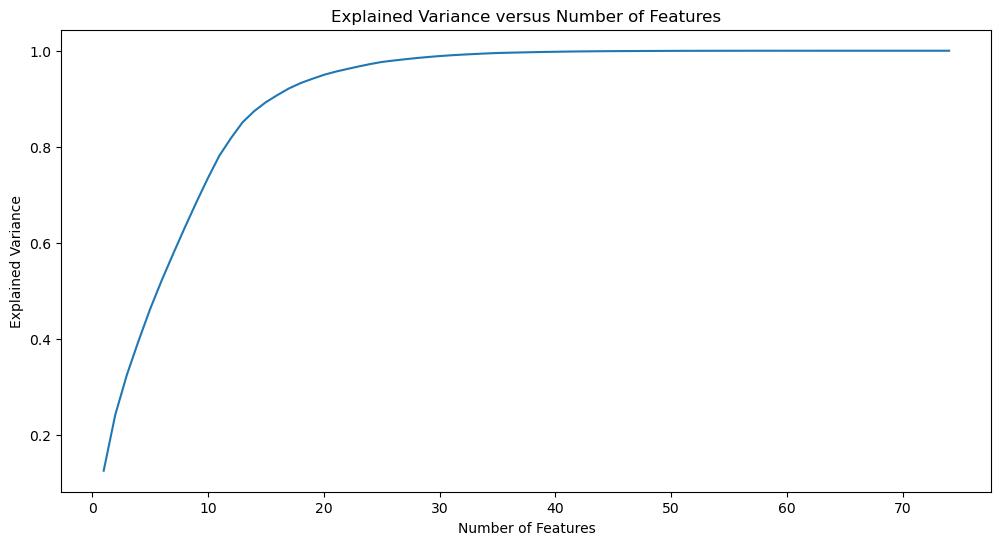

In [44]:
#Instantiate Principal Component Analysis.
pca=PCA()
X_pca = pca.fit_transform(X_trainres)
fig = plt.figure(figsize=(12,6))
plt.plot(range(1,X_trainres.shape[1]+1), pca.explained_variance_ratio_.cumsum())
plt.title('Explained Variance versus Number of Features')
plt.ylabel('Explained Variance')
plt.xlabel('Number of Features')
plt.show();

In [45]:
for n in [10,15,20,25]:
    pca_n = PCA(n_components=n)
    X_pcan = pca_n.fit_transform(X_trainres)
    tev = round(np.sum(pca_n.explained_variance_ratio_)*100,2)
    print('Number of Fetaures: ',n, 'Total Explained Variance: ',tev,'%')

Number of Fetaures:  10 Total Explained Variance:  73.5 %
Number of Fetaures:  15 Total Explained Variance:  89.28 %
Number of Fetaures:  20 Total Explained Variance:  94.97 %
Number of Fetaures:  25 Total Explained Variance:  97.65 %


From this graph I notice that the total explained variace starts to increase at a diminishing rate at around n_components=15. It also reduces dimensionality by a fourth of the size with just above 90% of the total variance explained. I would like the pipelines to try with n_components of 15,20,and 25.

## 5. Classification Models

Now that the data is prepped for modelling I will start by creating pipelines with grid search to tune the hyperparameters of each of the models. 

In [46]:
#Create pipeline for each of the classifiers.
#pipelines = {'logisticregression': Pipeline([('pca', PCA()),
                                            #('clf', LogisticRegression(random_state=123))]),
            #'decisiontree':Pipeline([('pca', PCA()),
                                            #('clf', DecisionTreeClassifier(random_state=123))]),
            #'randomforest':Pipeline([('pca', PCA()),
                                            #('clf', RandomForestClassifier(random_state=123))]),
            #'gradientboosting': Pipeline([('pca', PCA()),
                                           # ('clf', GradientBoostingClassifier(random_state=123))])}

#Define Hyperparameters for each pipeline
#hyperparameters_lr ={'pca__n_components': [15, 20, 25],
                     #'clf__C': [0.01,0.1,1]}

#hyperparameters_dt ={'pca__n_components': [10, 15, 20],
                    # 'clf__criterion': ['entropy', 'gini'], 
                    # 'clf__max_depth': [4, 5, 6],  
                    # 'clf__min_samples_leaf':[0.05 ,0.1, 0.2],  
                    # 'clf__min_samples_split':[0.05 ,0.1, 0.2]}

#hyperparameters_rf ={'pca__n_components': [10, 15, 20],
                    # 'clf__n_estimators': [100,150],
                    # 'clf__criterion': ['entropy', 'gini'], 
                    # 'clf__max_depth': [4, 5, 6],  
                    # 'clf__min_samples_leaf':[0.05 ,0.1, 0.2],  
                    # 'clf__min_samples_split':[0.05 ,0.1, 0.2]}

#hyperparameters_gb ={'pca__n_components': [10, 15, 20],
                    # 'clf__n_estimators': [100,150], 
                    # 'clf__max_depth': [1, 3, 5],  
                    # 'clf__learning_rate': [0.05,0.1]}

#Instantiate hyperparapeter dictionary
#hyperparameters = {'logisticregression':hyperparameters_lr ,
                   #'decisiontree':hyperparameters_dt,
                   #'randomforest':hyperparameters_rf,
                   #'gradientboosting': hyperparameters_gb}

In [47]:
#model_scores_auc, fitted_models_auc = grid_pipe(pipelines,hyperparameters,scoring='roc_auc')

In [48]:
#score_times_df_auc = pd.DataFrame(model_scores_auc,
                           #   columns=['classifier','roc_auc_score',
                                      # 'time']).set_index('classifier').sort_values('time')
#score_times_df_auc

The best performing classifier is gradient boosting with almost 95% roc_auc score. It is expected that ensemble models perform better than single classifiers. However, this comes at greater computational cost. The second best performing model is also an ensemble model, random forest, but given it almost identical score to logistic regression and that it took close to 100 times more time to fit, I consider the second best model to be logistic regression.

In [49]:
#for name, model in fitted_models_auc.items():
    #if name in ['logisticregression','gradientboosting']:
       # pred = model.predict(X_test)
       # print(name,':')
       # plot_confusion_matrix_from_data(y_test,pred, columns=['Non-Revenue','Revenue'], cmap='Oranges')

In [50]:
#model_scores_f1, fitted_models_f1 = grid_pipe(pipelines,hyperparameters,scoring='f1')

In [51]:
#score_times_df_f1 = pd.DataFrame(model_scores_f1,
                             # columns=['classifier','f1_score',
                                      # 'time']).set_index('classifier').sort_values('time')
#score_times_df_f1

In [52]:
#for name, model in fitted_models_f1.items():
    #if name in ['logisticregression','gradientboosting']:
       # pred = model.predict(X_test)
       # print(name,':')
        #plot_confusion_matrix_from_data(y_test,pred,columns=['Non-Revenue','Revenue'], cmap='Oranges')

In [53]:
#fitted_models_f1['gradientboosting'].best_params_

## 6. Conclusion and Recommendations
At first, I looked into the f1 score in order to improve the balnce of the imbalanced dataset. I checked for multicolinearity and delt with high correletaion features accordingly. The f1 score increase by about 6% and the roc_auc score by 8% just through scrubbing the data.

Once the data was ready to enter the pipelines to perform hyperparameter tuning, I conducted principal component analysis to derive the best n_component values to pass on to the pipelines. Turns out the with n_components =25 the data contains a little over 96% of the total explained variance, with half the number of total features. And, with n_components =15, the dataset contains over 90% of the total explained variance. So, decided to imput values in that range.

After running the grid search pipeline, the two best performing models are gradient boosting and logistic regression. Gradient boosting surpasses logistic regression in every metric, except running time. Hence, it will be important to consider the trade-off between computational cost and time.

In , my opinion, I recommend to test the Gradient Boosting Classifier in server conditions. If the model takes a long time to make the classiification, then Logistic Regression is preferred. Identification of the class of session as the user navigates the website has to be immediate in order to deploy marketing tactics that incentivize revenue generating behaviour being carefull not to be a deterrant. If the user is exhibiting favorable behaviour there is no need for aggresive tactics that could scare him.

In [54]:
#score_times_df_f1.loc[['gradientboosting','logisticregression']]

In [55]:
#score_times_df_auc.loc[['gradientboosting','logisticregression']]

## 7 Further Work
In order to keep improving the model, this are the following actionable steps:
+ Try a different SMOTE sampling startegy that resust in a different target incidency.
+ Create duartion per page for Administrative and Informative related pages.
+ Create a new pipeline with only logistic regressor and gradient boosting classifier and try other different parameters that approximate the pipe's resulting best parameters.

## 8. Bibliography and References
* Dataset: Sakar, C.O., Polat, S.O., Katircioglu, M. et al. Neural Comput & Applic (2018). https://link.springer.com/article/10.1007%2Fs00521-018-3523-0